# Smartphone Usage and Addiction Analysis
## Setup and Data Loading

* Importing libraries 
* Loading the raw dataset 
* Doing a quick initial inspection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

display(df_raw.head())

print(f"Dataset Shape: {df_raw.shape}")

print("Column Names:")
print(df_raw.columns.tolist())

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


Dataset Shape: (7500, 16)
Column Names:
['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


## Cleaning and Data Quality

 Check data quality, inspect ranges, clean the gender column to strictly binary (Male/Female), and create the df_clean dataframe.

In [2]:
print(f"Shape before cleaning: {df_raw.shape}")

df_raw.columns = df_raw.columns.str.strip()

# Check data types
print("\n--- Data Types ---")
df_raw.info()

# Check missing values
print("\n--- Missing Values ---")
print(df_raw.isnull().sum())

# Check duplicates
print("\n--- Duplicate Checks ---")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
print(f"Duplicate transaction_ids: {df_raw['transaction_id'].duplicated().sum()}")
print(f"Duplicate user_ids: {df_raw['user_id'].duplicated().sum()}")

# Check unique values at categorical columns
categorical_cols = ['gender', 'stress_level', 'academic_work_impact', 'addiction_level']
print("\n--- Categorical Unique Values ---")
for col in categorical_cols:
    if col in df_raw.columns:
        # Strip spaces from categorical values to fix simple formatting issues
        if df_raw[col].dtype == 'object':
            df_raw[col] = df_raw[col].str.strip()
        print(f"{col}: {df_raw[col].unique()}")

# Check basic numeric ranges
print("\n--- Numeric Ranges ---")
display(df_raw.describe())

Shape before cleaning: (7500, 16)

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact    

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [3]:
# Clean gender as a binary field
df_clean = df_raw.copy()

# Standardize
gender_mapping = {
    'male': 'Male', 'Male': 'Male', 'M': 'Male',
    'female': 'Female', 'Female': 'Female', 'F': 'Female'
}

df_clean['gender'] = df_clean['gender'].replace(gender_mapping)

# Find rows where gender is NOT 'Male' or 'Female'
valid_genders = ['Male', 'Female']
invalid_gender_mask = ~df_clean['gender'].isin(valid_genders)
invalid_gender_count = invalid_gender_mask.sum()

# Remove rows
df_clean = df_clean[~invalid_gender_mask]

print(f"Rows removed due to non-binary/invalid gender: {invalid_gender_count}")
print(f"Final unique genders in df_clean: {df_clean['gender'].unique()}")

print(f"\nFinal df_clean shape: {df_clean.shape}")

Rows removed due to non-binary/invalid gender: 2486
Final unique genders in df_clean: ['Male' 'Female']

Final df_clean shape: (5014, 16)


### Person 1 Handoff to Person 2

1. Rows and columns after cleaning: 5014 rows and 16 columns.
2. Missing values still exist in `addiction_level`: 547 missing values after removing invalid gender rows. No other columns have missing values.
3. Duplicate rows: 0. Duplicate `transaction_id`: 0. Duplicate `user_id`: 0.
4. Final unique values in `gender`: `Male` and `Female`.
5. Rows removed because `gender` was not `Male` or `Female`: 2486 rows with `Other` gender values.
6. Unusual values found: `Other` appeared in `gender` and was removed because this project uses binary gender only. `addiction_level` contains missing values, which should be handled in the preprocessing phase.
7. `df_clean` is ready for Person 2 to continue preprocessing and feature preparation.


## 2. Preprocessing and Feature Preparation - Person 2

This section starts from `df_clean`, handles the remaining missing values, prepares useful engineered features, encodes `gender` for modeling, and creates `df_prepared`, `X`, and `y` for the next phases.

Important modeling rule: `transaction_id`, `user_id`, `addicted_label`, `addiction_level`, and the original text `gender` column are excluded from the feature matrix. `addiction_level` is excluded because it is closely related to the target and may leak target information.

In [4]:
# Start from the cleaned dataframe created by Person 1
df_prepared = df_clean.copy()

numeric_columns = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'addicted_label'
]

categorical_columns = [
    'gender',
    'stress_level',
    'academic_work_impact',
    'addiction_level'
]

identifier_columns = ['transaction_id', 'user_id']

print('Missing values before preprocessing:')
display(df_prepared.isna().sum().to_frame('missing_count'))

# Do not impute the target. If target values are missing, remove those rows.
target_missing = df_prepared['addicted_label'].isna().sum()
if target_missing > 0:
    df_prepared = df_prepared.dropna(subset=['addicted_label']).copy()

# Numeric columns use median imputation if missing values are present.
numeric_imputation_values = {}
for col in numeric_columns:
    if col != 'addicted_label' and df_prepared[col].isna().sum() > 0:
        median_value = df_prepared[col].median()
        df_prepared[col] = df_prepared[col].fillna(median_value)
        numeric_imputation_values[col] = median_value

# Categorical columns use a simple category for missing values.
# For addiction_level, Unknown preserves the fact that the original value was missing.
categorical_imputation_values = {}
for col in categorical_columns:
    if col != 'gender' and df_prepared[col].isna().sum() > 0:
        fill_value = 'Unknown'
        df_prepared[col] = df_prepared[col].fillna(fill_value)
        categorical_imputation_values[col] = fill_value

# Confirm gender is still binary before encoding.
valid_genders = ['Female', 'Male']
remaining_invalid_gender_count = (~df_prepared['gender'].isin(valid_genders)).sum()
print(f'Remaining invalid gender values: {remaining_invalid_gender_count}')

gender_binary_map = {'Female': 0, 'Male': 1}
df_prepared['gender_binary'] = df_prepared['gender'].map(gender_binary_map).astype(int)

print('\nNumeric columns:')
print(numeric_columns)

print('\nCategorical columns:')
print(categorical_columns)

print('\nNumeric imputation values used:')
print(numeric_imputation_values if numeric_imputation_values else 'No numeric imputation needed')

print('\nCategorical imputation values used:')
print(categorical_imputation_values if categorical_imputation_values else 'No categorical imputation needed')

print('\nMissing values after preprocessing:')
display(df_prepared.isna().sum().to_frame('missing_count'))

print('\nGender encoding check:')
display(df_prepared[['gender', 'gender_binary']].drop_duplicates().sort_values('gender_binary'))

Missing values before preprocessing:


,missing_count
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


Remaining invalid gender values: 0

Numeric columns:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'addicted_label']

Categorical columns:
['gender', 'stress_level', 'academic_work_impact', 'addiction_level']

Numeric imputation values used:
No numeric imputation needed

Categorical imputation values used:
{'addiction_level': 'Unknown'}

Missing values after preprocessing:


,missing_count
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0



Gender encoding check:


,gender,gender_binary
10,Female,0
0,Male,1


### Feature Preparation

The original cleaned columns are kept in `df_prepared` for EDA. New features are added to summarize usage behavior and create intensity measures. Ratio features safely handle division by zero by replacing invalid ratios with `0`.

`gender_binary` uses this encoding: `Female = 0`, `Male = 1`. The original `gender` column is kept for charts and grouped summaries, but it is not used directly in the modeling matrix.

In [5]:
# Simple engineered features
df_prepared['usage_component_total_hours'] = (
    df_prepared['social_media_hours']
    + df_prepared['gaming_hours']
    + df_prepared['work_study_hours']
)

screen_time_nonzero = df_prepared['daily_screen_time_hours'].replace(0, np.nan)

df_prepared['notifications_per_screen_hour'] = (
    df_prepared['notifications_per_day'] / screen_time_nonzero
).replace([np.inf, -np.inf], np.nan).fillna(0)

df_prepared['app_opens_per_screen_hour'] = (
    df_prepared['app_opens_per_day'] / screen_time_nonzero
).replace([np.inf, -np.inf], np.nan).fillna(0)

df_prepared['sleep_below_7_hours'] = (df_prepared['sleep_hours'] < 7).astype(int)

excluded_modeling_columns = [
    'transaction_id',
    'user_id',
    'addicted_label',
    'addiction_level',
    'gender'
]

numeric_model_features = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'gender_binary',
    'usage_component_total_hours',
    'notifications_per_screen_hour',
    'app_opens_per_screen_hour',
    'sleep_below_7_hours'
]

categorical_model_features = ['stress_level', 'academic_work_impact']
model_feature_columns = numeric_model_features + categorical_model_features

# Keep an unencoded feature dataframe available for sklearn ColumnTransformer pipelines.
X_unencoded = df_prepared[model_feature_columns].copy()

# Create a fully numeric feature matrix for simple models.
X = pd.get_dummies(
    X_unencoded,
    columns=categorical_model_features,
    drop_first=False,
    dtype=int
)

y = df_prepared['addicted_label'].astype(int).copy()

print(f'df_prepared shape: {df_prepared.shape}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

print('\nExcluded modeling columns:')
print(excluded_modeling_columns)

print('\nRecommended unencoded feature columns for Person 4 pipeline option:')
print(model_feature_columns)

print('\nFinal numeric X columns:')
print(X.columns.tolist())

display(df_prepared.head())
display(X.head())
display(y.value_counts().sort_index().rename('target_count').to_frame())

df_prepared shape: (5014, 21)
X shape: (5014, 19)
y shape: (5014,)

Excluded modeling columns:
['transaction_id', 'user_id', 'addicted_label', 'addiction_level', 'gender']

Recommended unencoded feature columns for Person 4 pipeline option:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender_binary', 'usage_component_total_hours', 'notifications_per_screen_hour', 'app_opens_per_screen_hour', 'sleep_below_7_hours', 'stress_level', 'academic_work_impact']

Final numeric X columns:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender_binary', 'usage_component_total_hours', 'notifications_per_screen_hour', 'app_opens_per_screen_hour', 'sleep_below_7_hours', 'stress_level_High', 'stress_level_Low', 'stress_level_Medium', 'academic

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,...,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,gender_binary,usage_component_total_hours,notifications_per_screen_hour,app_opens_per_screen_hour,sleep_below_7_hours
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,...,3.95,Medium,Yes,Unknown,0,1,7.45,76.780186,47.678019,0
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,...,12.55,Low,No,Severe,1,1,14.61,13.654618,17.771084,1
5,TXN00006,U00006,26,Male,9.32,4.26,0.29,3.99,6.90,82,...,10.98,Medium,Yes,Severe,1,1,8.54,8.798283,6.008584,1
6,TXN00007,U00007,25,Male,10.40,4.93,1.60,0.86,8.61,165,...,11.43,Medium,No,Severe,1,1,7.39,15.865385,9.134615,0
7,TXN00008,U00008,26,Male,4.26,4.60,2.16,4.61,6.43,169,...,5.66,Low,No,Moderate,1,1,11.37,39.671362,27.464789,1


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender_binary,usage_component_total_hours,notifications_per_screen_hour,app_opens_per_screen_hour,sleep_below_7_hours,stress_level_High,stress_level_Low,stress_level_Medium,academic_work_impact_No,academic_work_impact_Yes
0,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,7.45,76.780186,47.678019,0,0,0,1,0,1
4,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,1,14.61,13.654618,17.771084,1,0,1,0,1,0
5,26,9.32,4.26,0.29,3.99,6.90,82,56,10.98,1,8.54,8.798283,6.008584,1,0,0,1,0,1
6,25,10.40,4.93,1.60,0.86,8.61,165,95,11.43,1,7.39,15.865385,9.134615,0,0,0,1,1,0
7,26,4.26,4.60,2.16,4.61,6.43,169,117,5.66,1,11.37,39.671362,27.464789,1,0,1,0,1,0


,target_count
addicted_label,
0,1442
1,3572


### Person 2 Handoff to Person 3 and Person 4

1. Preprocessing started from `df_clean`, which already removed non-binary `gender` values according to the project rule.
2. Missing `addiction_level` values were filled with `Unknown` in `df_prepared` so Person 3 can still include those rows in EDA. This column should still be excluded from modeling because it may leak target information.
3. No target imputation was applied to `addicted_label`.
4. `gender` was encoded as `gender_binary`, where `Female = 0` and `Male = 1`. The original `gender` column remains available for EDA labels.
5. New features created: `usage_component_total_hours`, `notifications_per_screen_hour`, `app_opens_per_screen_hour`, and `sleep_below_7_hours`.
6. Columns excluded from modeling: `transaction_id`, `user_id`, `addicted_label`, `addiction_level`, and `gender`.
7. `df_prepared` is ready for Person 3. `X`, `X_unencoded`, `y`, `model_feature_columns`, and `excluded_modeling_columns` are ready for Person 4.


## 3. Descriptive Analytics and EDA - Person 3

This section uses `df_prepared` from Person 2 to summarize the cleaned and preprocessed dataset. The goal is to understand the target distribution, compare usage patterns across important groups, and identify variables that may be useful for predictive modeling.

The analysis keeps `addiction_level` for descriptive EDA only. It is not a modeling feature because it closely tracks `addicted_label` and would leak target information into the predictive model.

In [6]:
# Phase 3 setup: key columns for descriptive analytics and EDA
eda_numeric_columns = [
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
]

eda_categorical_columns = [
    'gender',
    'stress_level',
    'academic_work_impact',
    'addiction_level',
    'addicted_label'
]

print(f'Prepared dataset rows: {df_prepared.shape[0]}')
print(f'Prepared dataset columns: {df_prepared.shape[1]}')

print()
print('Summary statistics for numeric usage columns:')
display(df_prepared[eda_numeric_columns].describe().round(2))

print()
print('Categorical value counts:')
for col in eda_categorical_columns:
    print()
    print(col)
    display(df_prepared[col].value_counts(dropna=False).rename('count').to_frame())

print()
print('Target distribution with percentages:')
target_distribution = pd.concat(
    [
        df_prepared['addicted_label'].value_counts().sort_index().rename('count'),
        (df_prepared['addicted_label'].value_counts(normalize=True).sort_index() * 100).round(2).rename('percentage')
    ],
    axis=1
)
display(target_distribution)


Prepared dataset rows: 5014
Prepared dataset columns: 21

Summary statistics for numeric usage columns:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
count,5014.00,5014.00,5014.00,5014.00,5014.00,5014.00,5014.00,5014.00
mean,7.50,3.28,2.02,3.24,6.77,134.42,97.91,9.25
std,2.61,1.58,1.14,1.60,1.28,67.06,48.84,2.72
min,3.00,0.50,0.00,0.50,4.50,20.00,15.00,3.63
25%,5.24,1.93,1.04,1.83,5.67,76.00,55.00,6.96
50%,7.53,3.27,2.03,3.23,6.76,135.00,97.00,9.28
75%,9.83,4.62,2.99,4.63,7.88,192.00,141.00,11.55
max,11.99,6.00,4.00,6.00,9.00,250.00,180.00,14.88



Categorical value counts:

gender


,count
gender,
Male,2553
Female,2461



stress_level


...

,count
addiction_level,
Moderate,1962
Severe,1610
Mild,895
Unknown,547



addicted_label


,count
addicted_label,
1,3572
0,1442



Target distribution with percentages:


,count,percentage
addicted_label,,
0,1442,28.76
1,3572,71.24


### Initial Descriptive Observations

The prepared dataset contains 5,014 rows after the Phase 1 binary-gender cleaning rule was applied. The target variable is imbalanced: `addicted_label = 1` has 3,572 rows, about 71.24% of the prepared dataset, while `addicted_label = 0` has 1,442 rows, about 28.76%.

The categorical variables are still useful for EDA. `gender`, `stress_level`, and `academic_work_impact` are fairly balanced, while `addiction_level` includes `Unknown` values created during preprocessing so those rows can stay in descriptive analysis.


In [7]:
# Average usage values by key groups
print('Average usage values by addicted_label:')
avg_by_addicted_label = df_prepared.groupby('addicted_label')[eda_numeric_columns].mean().round(2)
display(avg_by_addicted_label)

print('Average usage values by gender:')
avg_by_gender = df_prepared.groupby('gender')[eda_numeric_columns].mean().round(2)
display(avg_by_gender)

print('Average usage values by stress_level:')
avg_by_stress = df_prepared.groupby('stress_level')[eda_numeric_columns].mean().round(2)
display(avg_by_stress)

print('Average usage values by academic_work_impact:')
avg_by_impact = df_prepared.groupby('academic_work_impact')[eda_numeric_columns].mean().round(2)
display(avg_by_impact)

print('Median usage values by addicted_label, included to reduce the effect of extreme values:')
median_by_addicted_label = df_prepared.groupby('addicted_label')[eda_numeric_columns].median().round(2)
display(median_by_addicted_label)


Average usage values by addicted_label:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
addicted_label,,,,,,,,
0,5.12,2.27,1.99,3.24,6.69,134.27,96.98,6.87
1,8.46,3.69,2.03,3.24,6.80,134.48,98.28,10.21


Average usage values by gender:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
gender,,,,,,,,
Female,7.45,3.26,2.02,3.27,6.75,133.3,98.44,9.19
Male,7.56,3.30,2.01,3.21,6.79,135.5,97.39,9.32


Average usage values by stress_level:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
stress_level,,,,,,,,
High,7.58,3.25,1.99,3.30,6.73,133.13,96.92,9.33
Low,7.51,3.31,2.02,3.22,6.81,135.46,98.11,9.28
Medium,7.43,3.28,2.03,3.20,6.77,134.67,98.71,9.15


Average usage values by academic_work_impact:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
academic_work_impact,,,,,,,,
No,7.54,3.26,2.03,3.27,6.80,134.21,98.18,9.29
Yes,7.47,3.30,2.00,3.21,6.74,134.64,97.63,9.21


Median usage values by addicted_label, included to reduce the effect of extreme values:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
addicted_label,,,,,,,,
0,5.04,2.32,1.98,3.28,6.68,135.5,95.5,6.75
1,8.87,4.05,2.05,3.21,6.80,134.0,99.0,10.58


In [8]:
# Normalized categorical comparisons with addicted_label
# Percentages make it easier to compare category relationships when category sizes differ.
categorical_relationship_columns = [
    'stress_level',
    'academic_work_impact',
    'gender',
    'addiction_level'
]

for col in categorical_relationship_columns:
    print(f'{col} vs addicted_label - counts')
    counts_table = pd.crosstab(df_prepared[col], df_prepared['addicted_label'])
    display(counts_table)

    print(f'{col} vs addicted_label - row percentages')
    percentage_table = (
        pd.crosstab(df_prepared[col], df_prepared['addicted_label'], normalize='index')
        .mul(100)
        .round(2)
    )
    display(percentage_table)
    print()


stress_level vs addicted_label - counts


addicted_label,0,1
stress_level,,
High,497,1176
Low,466,1233
Medium,479,1163


stress_level vs addicted_label - row percentages


addicted_label,0,1
stress_level,,
High,29.71,70.29
Low,27.43,72.57
Medium,29.17,70.83



academic_work_impact vs addicted_label - counts


...

addicted_label,0,1
gender,,
Female,29.78,70.22
Male,27.77,72.23



addiction_level vs addicted_label - counts


addicted_label,0,1
addiction_level,,
Mild,895,0
Moderate,0,1962
Severe,0,1610
Unknown,547,0


addiction_level vs addicted_label - row percentages


addicted_label,0,1
addiction_level,,
Mild,100.0,0.0
Moderate,0.0,100.0
Severe,0.0,100.0
Unknown,100.0,0.0


### Categorical Relationship Observations

The normalized category tables support the visual interpretation. `stress_level`, `academic_work_impact`, and `gender` have similar addicted-label percentages across their categories, so they do not show strong descriptive separation in this dataset.

`addiction_level` is different: `Mild` and `Unknown` align with `addicted_label = 0`, while `Moderate` and `Severe` align with `addicted_label = 1`. This makes `addiction_level` useful for explaining the labels descriptively, but it should remain excluded from predictive modeling because it behaves like a target proxy.

### Grouped Summary Observations

The clearest differences are between `addicted_label` groups. Users with `addicted_label = 1` average about 8.46 daily screen-time hours, 10.21 weekend screen-time hours, and 3.69 social-media hours. Users with `addicted_label = 0` average about 5.12 daily screen-time hours, 6.87 weekend screen-time hours, and 2.27 social-media hours.

Gaming hours, work/study hours, sleep hours, notifications per day, and app opens per day are much closer between the two target groups. Average usage values by `gender`, `stress_level`, and `academic_work_impact` are also similar, so these variables look less separated than screen-time-related variables in the descriptive summaries.

### EDA Charts

These charts focus on whether the prepared data shows visible differences between users labeled as addicted and non-addicted. The main things to check are target imbalance, whether screen-time-related variables separate the two target groups, whether sleep and notification behavior look different, and whether categorical variables such as stress level, academic/work impact, and gender show clear patterns with `addicted_label`.


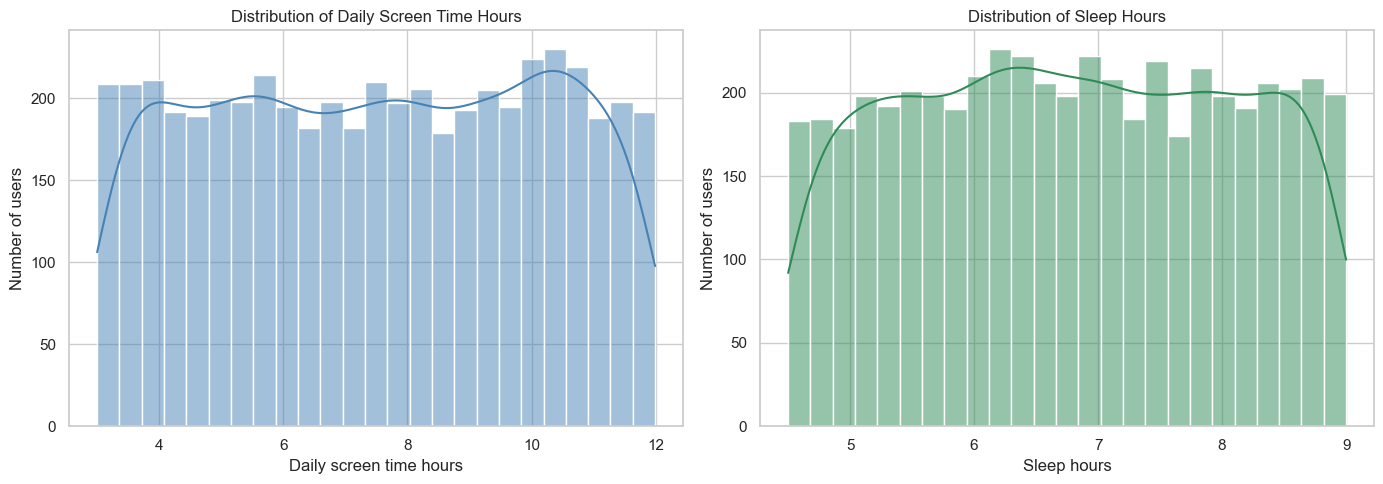

In [9]:
# Distribution charts for daily screen time and sleep hours
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_prepared,
    x='daily_screen_time_hours',
    bins=25,
    kde=True,
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Distribution of Daily Screen Time Hours')
axes[0].set_xlabel('Daily screen time hours')
axes[0].set_ylabel('Number of users')

sns.histplot(
    data=df_prepared,
    x='sleep_hours',
    bins=25,
    kde=True,
    ax=axes[1],
    color='seagreen'
)
axes[1].set_title('Distribution of Sleep Hours')
axes[1].set_xlabel('Sleep hours')
axes[1].set_ylabel('Number of users')

plt.tight_layout()
plt.show()


### Distribution Chart Observations

Daily screen time ranges from about 3.00 to 11.99 hours, while sleep hours range from about 4.50 to 9.00 hours. The screen-time variables have clearer separation by `addicted_label`, while sleep hours stay much closer across the two target groups.

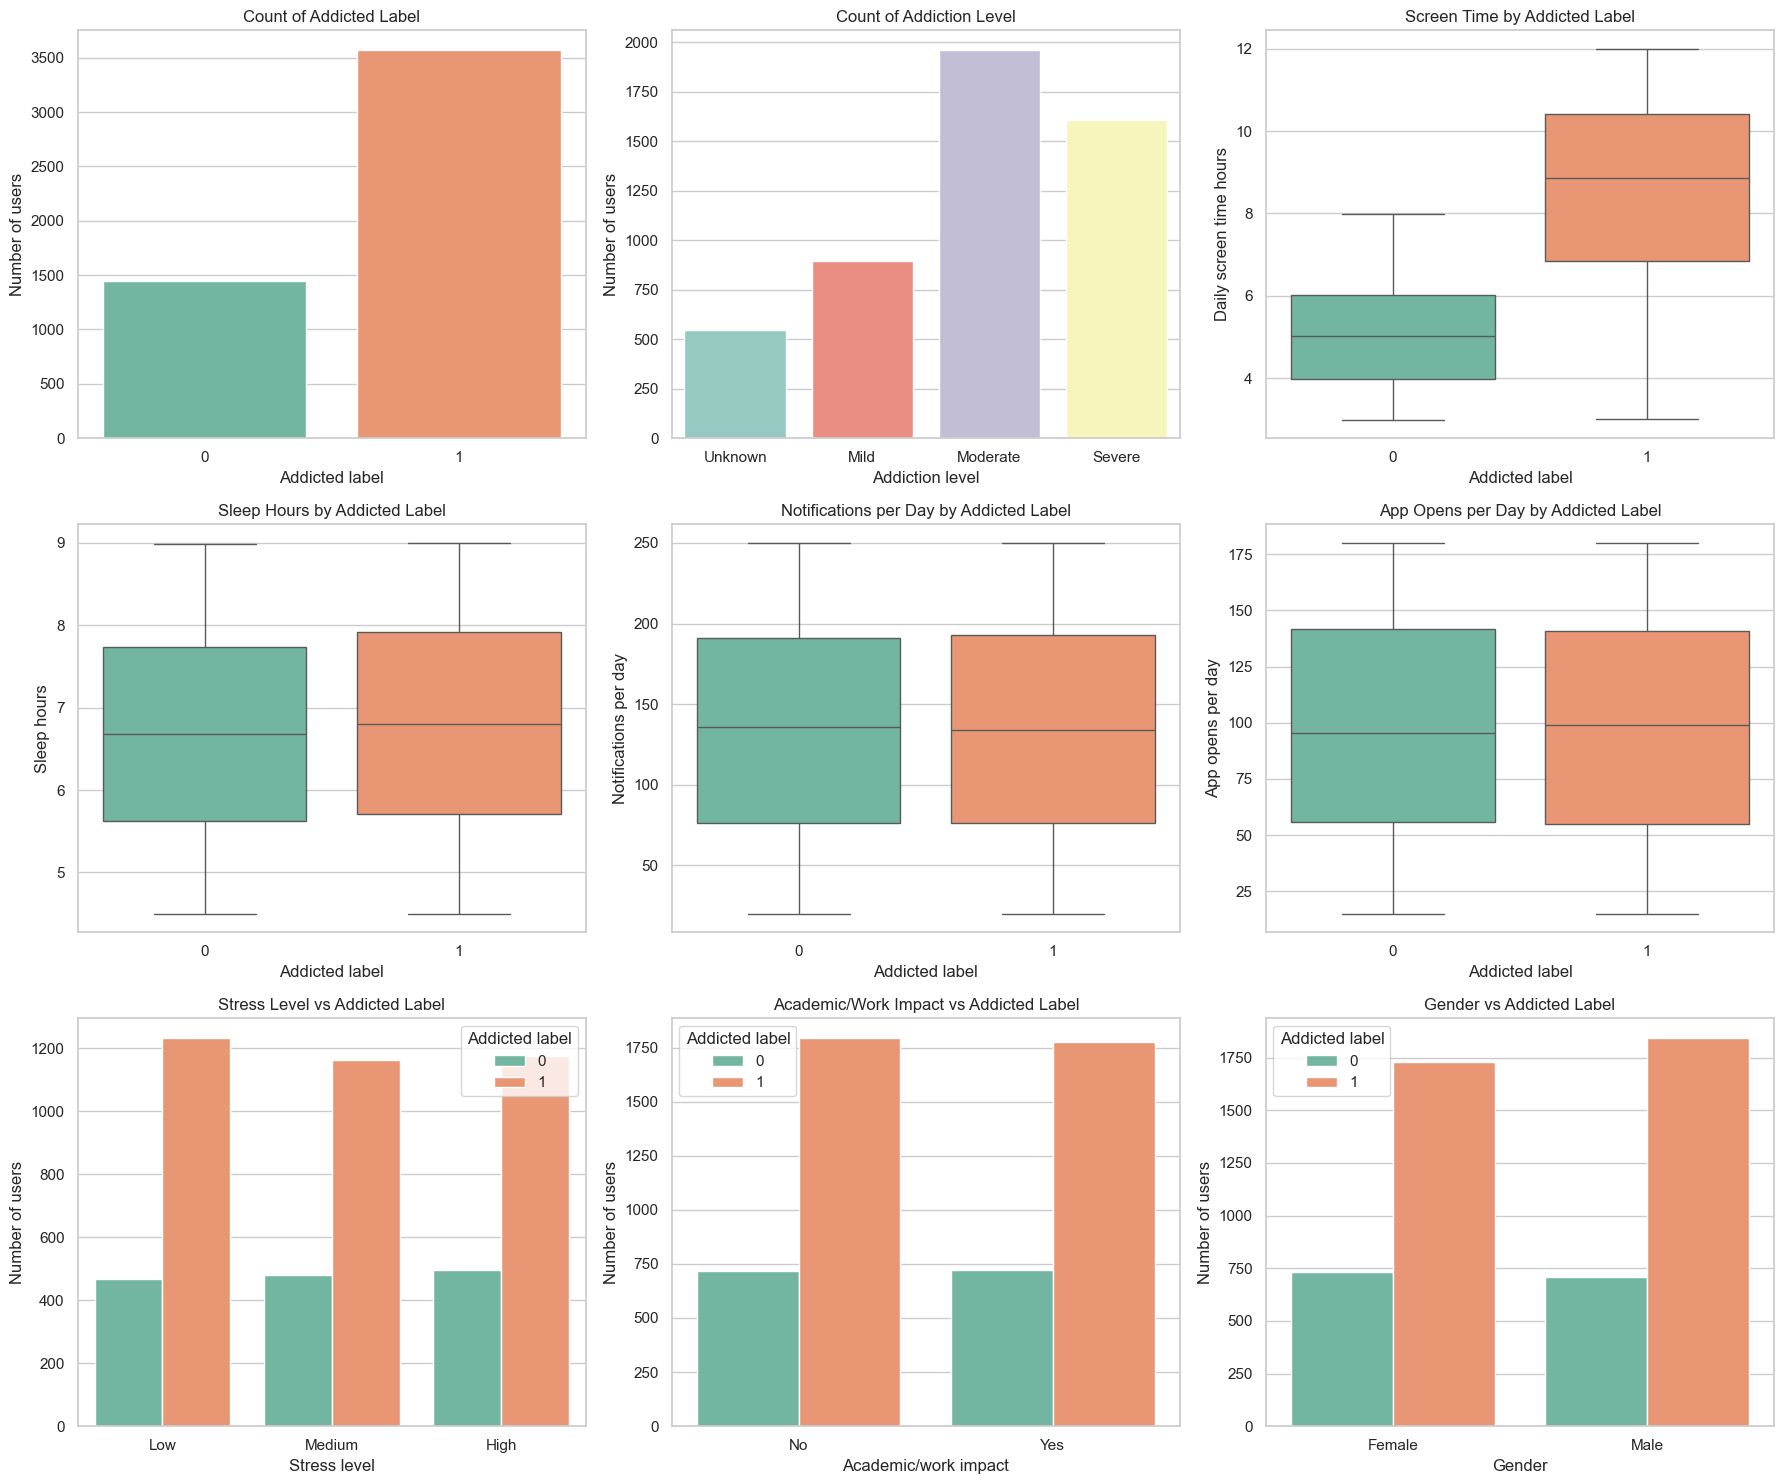

In [10]:
# Count charts and comparison charts by addicted_label
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

sns.countplot(data=df_prepared, x='addicted_label', ax=axes[0], palette='Set2', hue='addicted_label', legend=False)
axes[0].set_title('Count of Addicted Label')
axes[0].set_xlabel('Addicted label')
axes[0].set_ylabel('Number of users')

sns.countplot(data=df_prepared, x='addiction_level', ax=axes[1], order=['Unknown', 'Mild', 'Moderate', 'Severe'], palette='Set3', hue='addiction_level', legend=False)
axes[1].set_title('Count of Addiction Level')
axes[1].set_xlabel('Addiction level')
axes[1].set_ylabel('Number of users')

sns.boxplot(data=df_prepared, x='addicted_label', y='daily_screen_time_hours', ax=axes[2], palette='Set2', hue='addicted_label', legend=False)
axes[2].set_title('Screen Time by Addicted Label')
axes[2].set_xlabel('Addicted label')
axes[2].set_ylabel('Daily screen time hours')

sns.boxplot(data=df_prepared, x='addicted_label', y='sleep_hours', ax=axes[3], palette='Set2', hue='addicted_label', legend=False)
axes[3].set_title('Sleep Hours by Addicted Label')
axes[3].set_xlabel('Addicted label')
axes[3].set_ylabel('Sleep hours')

sns.boxplot(data=df_prepared, x='addicted_label', y='notifications_per_day', ax=axes[4], palette='Set2', hue='addicted_label', legend=False)
axes[4].set_title('Notifications per Day by Addicted Label')
axes[4].set_xlabel('Addicted label')
axes[4].set_ylabel('Notifications per day')

sns.boxplot(data=df_prepared, x='addicted_label', y='app_opens_per_day', ax=axes[5], palette='Set2', hue='addicted_label', legend=False)
axes[5].set_title('App Opens per Day by Addicted Label')
axes[5].set_xlabel('Addicted label')
axes[5].set_ylabel('App opens per day')

sns.countplot(data=df_prepared, x='stress_level', hue='addicted_label', ax=axes[6], order=['Low', 'Medium', 'High'], palette='Set2')
axes[6].set_title('Stress Level vs Addicted Label')
axes[6].set_xlabel('Stress level')
axes[6].set_ylabel('Number of users')
axes[6].legend(title='Addicted label')

sns.countplot(data=df_prepared, x='academic_work_impact', hue='addicted_label', ax=axes[7], order=['No', 'Yes'], palette='Set2')
axes[7].set_title('Academic/Work Impact vs Addicted Label')
axes[7].set_xlabel('Academic/work impact')
axes[7].set_ylabel('Number of users')
axes[7].legend(title='Addicted label')

sns.countplot(data=df_prepared, x='gender', hue='addicted_label', ax=axes[8], order=['Female', 'Male'], palette='Set2')
axes[8].set_title('Gender vs Addicted Label')
axes[8].set_xlabel('Gender')
axes[8].set_ylabel('Number of users')
axes[8].legend(title='Addicted label')

plt.tight_layout()
plt.show()


### Comparison Chart Observations

The count chart confirms that `addicted_label = 1` is the majority class. The boxplots show clearer separation for daily screen time than for sleep hours, notifications, or app opens. The categorical count charts for stress level, academic/work impact, and gender do not show strong visible separation across the two target labels.

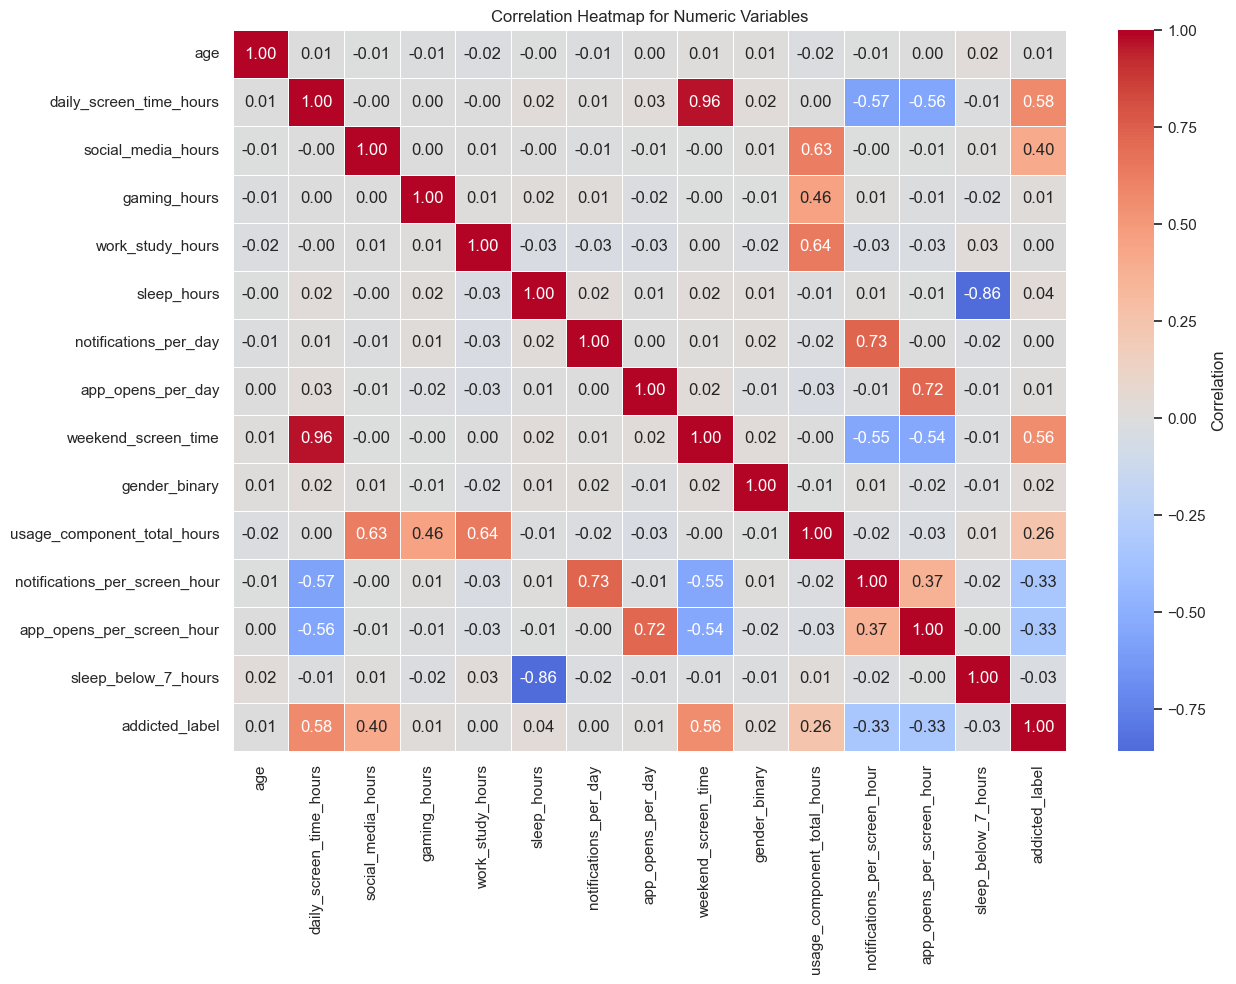

Correlation with addicted_label, sorted by absolute strength:


,correlation_with_addicted_label
daily_screen_time_hours,0.578
weekend_screen_time,0.556
social_media_hours,0.405
notifications_per_screen_hour,-0.329
app_opens_per_screen_hour,-0.329
usage_component_total_hours,0.259
sleep_hours,0.038
sleep_below_7_hours,-0.029
gender_binary,0.022
gaming_hours,0.014


In [11]:
# Correlation heatmap for numeric variables
correlation_columns = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'gender_binary',
    'usage_component_total_hours',
    'notifications_per_screen_hour',
    'app_opens_per_screen_hour',
    'sleep_below_7_hours',
    'addicted_label'
]

correlation_matrix = df_prepared[correlation_columns].corr(numeric_only=True)

plt.figure(figsize=(13, 10))
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation Heatmap for Numeric Variables')
plt.tight_layout()
plt.show()

print('Correlation with addicted_label, sorted by absolute strength:')
correlation_with_target = (
    correlation_matrix['addicted_label']
    .drop('addicted_label')
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .round(3)
)
display(correlation_with_target.rename('correlation_with_addicted_label').to_frame())


### Correlation Heatmap Observations

The strongest numeric relationships with `addicted_label` are `daily_screen_time_hours` (about 0.578), `weekend_screen_time` (about 0.556), and `social_media_hours` (about 0.405). The engineered ratio features also show moderate negative correlations, but they use daily screen time as the denominator, so Person 4 should treat them as derived screen-time-intensity features rather than independent evidence.

Correlation does not prove causation, but it helps identify non-leaking variables that may be useful for classification models.

### Phase 3 Questions Answered

1. The target variable is imbalanced. About 71.24% of the prepared rows have `addicted_label = 1`, while about 28.76% have `addicted_label = 0`.
2. Addicted and non-addicted groups appear different in screen time. The `addicted_label = 1` group has higher average daily screen time (8.46 vs 5.12 hours) and weekend screen time (10.21 vs 6.87 hours).
3. Addicted and non-addicted groups do not appear very different in sleep hours. The averages and medians are close, so sleep hours may be weaker by itself for modeling in this dataset.
4. `stress_level` and `academic_work_impact` do not show strong separation with `addicted_label` in the grouped summaries, row percentages, or count charts. They may still be included as categorical model features, but the descriptive relationship looks weaker than screen-time-related variables.
5. The variables that seem most useful for modeling are `daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours`, and possibly the engineered usage-intensity features. `addiction_level` should not be used for prediction because it behaves like a target proxy.

### Person 3 Handoff to Person 4

1. Main EDA observations: `addicted_label = 1` is the majority class; daily screen time, weekend screen time, and social media hours are higher for the `addicted_label = 1` group; sleep hours, notifications, app opens, gender, stress level, and academic/work impact show weaker differences in the descriptive summaries.
2. Possible outliers: the checked numeric columns do not show obvious extreme outlier problems from the distribution charts. Values appear within reasonable simulated ranges, but model performance should still be evaluated carefully.
3. Target balance: the target is imbalanced, with about 71.24% labeled `1` and 28.76% labeled `0`. Person 4 should use `stratify=y` during the train/test split and compare models against a majority-class baseline.
4. Features that seem important from EDA: `daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours`, `usage_component_total_hours`, `notifications_per_screen_hour`, and `app_opens_per_screen_hour` may be useful. The ratio features should be interpreted carefully because they are derived from daily screen time.
5. Leakage warning: `addiction_level` should not be used in the predictive model. In this prepared dataset it behaves like a target proxy, with `Mild` and `Unknown` aligned to `addicted_label = 0` and `Moderate` and `Severe` aligned to `addicted_label = 1`.
6. `df_prepared`, `X`, `X_unencoded`, `y`, and `model_feature_columns` are ready for Phase 4 predictive analytics.

## 4. Predictive Analytics - Person 4

This section builds simple classification models to predict `addicted_label` using the non-leaking feature set prepared by Person 2. The main goal is to compare several course-appropriate models, choose one suitable model, tune only that selected model, and interpret the results clearly.

Important leakage rule: `transaction_id`, `user_id`, `gender`, `addiction_level`, and `addicted_label` are not used as input features. `addiction_level` is excluded because Person 3 showed that it behaves like a target proxy.

### Modeling Setup and Leakage Check

The train/test split uses 80% training data and 20% testing data with `random_state=42`. Because the target is imbalanced, the split uses `stratify=y` so the class proportions stay similar in both sets.

In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Confirm the modeling feature matrix follows the project leakage rules.
leakage_columns = ['transaction_id', 'user_id', 'gender', 'addiction_level', 'addicted_label']
leakage_columns_in_X = [col for col in leakage_columns if col in X.columns]

print('Leakage columns found in X:')
print(leakage_columns_in_X if leakage_columns_in_X else 'None')

print()
print('Feature matrix and target shape:')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

print()
print('Target class balance before split:')
target_balance = pd.concat(
    [
        y.value_counts().sort_index().rename('count'),
        (y.value_counts(normalize=True).sort_index() * 100).round(2).rename('percentage')
    ],
    axis=1
)
display(target_balance)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print()
print('Train/test shapes:')
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

print()
print('Target balance in test set:')
test_balance = pd.concat(
    [
        y_test.value_counts().sort_index().rename('count'),
        (y_test.value_counts(normalize=True).sort_index() * 100).round(2).rename('percentage')
    ],
    axis=1
)
display(test_balance)


Leakage columns found in X:


None

Feature matrix and target shape:
X shape: (5014, 19)
y shape: (5014,)

Target class balance before split:


,count,percentage
addicted_label,,
0,1442,28.76
1,3572,71.24



Train/test shapes:
X_train: (4011, 19)
X_test: (1003, 19)
y_train: (4011,)
y_test: (1003,)

Target balance in test set:


,count,percentage
addicted_label,,
0,288,28.71
1,715,71.29


### Baseline and First-Pass Model Comparison

A majority-class baseline is included so the classification models must beat a simple rule that always predicts the most common class. Logistic regression, decision tree, Naive Bayes, KNN, and a small neural network are then compared using the same train/test split.

In [13]:
def evaluate_classifier(model_name, fitted_model, X_eval, y_eval):
    predictions = fitted_model.predict(X_eval)
    tn, fp, fn, tp = confusion_matrix(y_eval, predictions).ravel()
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_eval, predictions),
        'precision': precision_score(y_eval, predictions, zero_division=0),
        'recall': recall_score(y_eval, predictions, zero_division=0),
        'f1': f1_score(y_eval, predictions, zero_division=0),
        'true_negative': tn,
        'false_positive': fp,
        'false_negative': fn,
        'true_positive': tp
    }

candidate_models = {
    'Majority class baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=7))
    ]),
    'Neural network': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=(32,),
            max_iter=1000,
            random_state=42,
            early_stopping=True
        ))
    ])
}

model_results = []
fitted_candidate_models = {}

for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)
    fitted_candidate_models[model_name] = model
    model_results.append(evaluate_classifier(model_name, model, X_test, y_test))

model_results_df = (
    pd.DataFrame(model_results)
    .sort_values(by='f1', ascending=False)
    .reset_index(drop=True)
)

display(model_results_df.round(4))


,model,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,Decision tree,0.9412,0.9607,0.9566,0.9587,260,28,31,684
1,Neural network,0.9192,0.9354,0.9524,0.9439,241,47,34,681
2,Logistic regression,0.9073,0.9296,0.9413,0.9354,237,51,42,673
3,Naive Bayes,0.8893,0.9290,0.9147,0.9218,238,50,61,654
4,KNN,0.8704,0.8814,0.9455,0.9123,197,91,39,676
5,Majority class baseline,0.7129,0.7129,1.0000,0.8324,0,288,0,715


### First-Pass Model Interpretation

All trained classification models beat the majority-class baseline. The first-pass decision tree has the strongest test-set F1-score, followed by the neural network and logistic regression. The decision tree is selected for tuning because it performs well and is easier to explain than the neural network.

### Tune the Selected Model

Only the selected decision tree is tuned. The grid search uses 5-fold cross-validation on the training data and optimizes F1-score because the target is imbalanced.

Best decision tree parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 10}
Best cross-validation F1-score: 0.9554


,model,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,Tuned decision tree,0.9322,0.9615,0.9427,0.952,261,27,41,674


Classification report for tuned decision tree:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       288
           1       0.96      0.94      0.95       715

    accuracy                           0.93      1003
   macro avg       0.91      0.92      0.92      1003
weighted avg       0.93      0.93      0.93      1003



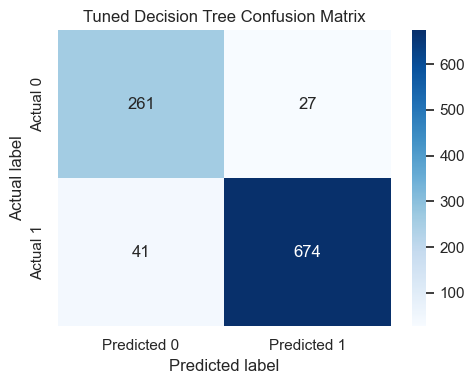

In [14]:
decision_tree_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_leaf': [1, 5, 10, 20]
}

decision_tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=decision_tree_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=None
)

decision_tree_grid.fit(X_train, y_train)

best_tree_model = decision_tree_grid.best_estimator_
best_tree_predictions = best_tree_model.predict(X_test)

print('Best decision tree parameters:')
print(decision_tree_grid.best_params_)
print(f"Best cross-validation F1-score: {decision_tree_grid.best_score_:.4f}")

final_tree_metrics = evaluate_classifier(
    'Tuned decision tree',
    best_tree_model,
    X_test,
    y_test
)

display(pd.DataFrame([final_tree_metrics]).round(4))

print('Classification report for tuned decision tree:')
print(classification_report(y_test, best_tree_predictions, zero_division=0))

final_confusion_matrix = confusion_matrix(y_test, best_tree_predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(
    final_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Tuned Decision Tree Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.tight_layout()
plt.show()


### Feature Importance

The decision tree's feature importance values help identify which variables contributed most to the selected model. These importances are model-specific, so they should be interpreted as predictive signals rather than causal effects.

Top 10 feature importances for the tuned decision tree:


,feature,importance
0,social_media_hours,0.4791
1,daily_screen_time_hours,0.4609
2,gaming_hours,0.0135
3,weekend_screen_time,0.0122
4,age,0.0063
5,notifications_per_screen_hour,0.0057
6,usage_component_total_hours,0.0051
7,work_study_hours,0.0045
8,academic_work_impact_Yes,0.0029
9,sleep_hours,0.0028


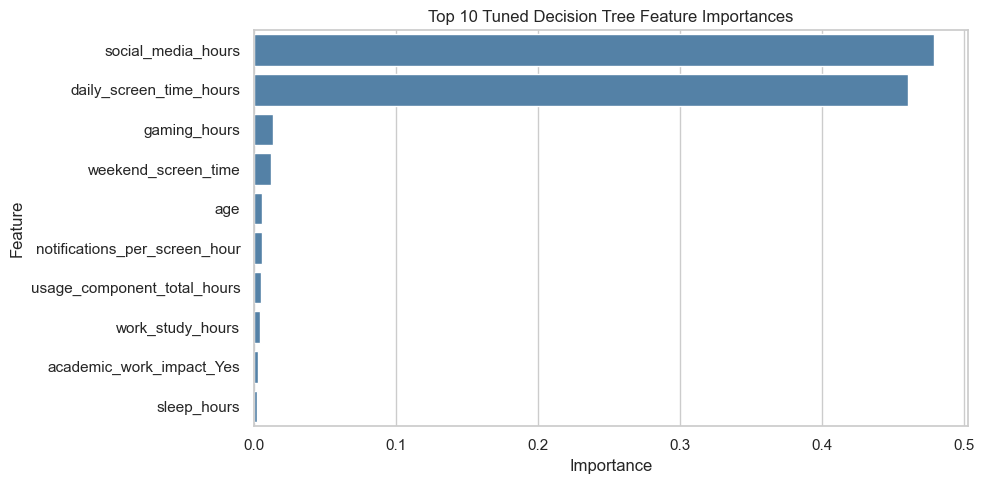

In [15]:
feature_importance_df = (
    pd.DataFrame({
        'feature': X.columns,
        'importance': best_tree_model.feature_importances_
    })
    .sort_values(by='importance', ascending=False)
    .reset_index(drop=True)
)

print('Top 10 feature importances for the tuned decision tree:')
display(feature_importance_df.head(10).round(4))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_importance_df.head(10),
    x='importance',
    y='feature',
    color='steelblue'
)
plt.title('Top 10 Tuned Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### Person 4 Modeling Interpretation

1. Best model: the decision tree was the best first-pass model by F1-score and was selected for tuning.
2. Tuned model performance: the tuned decision tree achieved about 93.22% accuracy, 96.15% precision, 94.27% recall, and 95.20% F1-score on the test set.
3. Baseline comparison: the tuned decision tree clearly beats the majority-class baseline, which mainly benefits from predicting the majority class and has no true negatives.
4. Confusion matrix interpretation: the tuned decision tree produced 261 true negatives, 674 true positives, 27 false positives, and 41 false negatives. It made more false negatives than false positives.
5. Important features: the decision tree relies most heavily on `social_media_hours` and `daily_screen_time_hours`, with smaller contributions from `gaming_hours`, `weekend_screen_time`, and several other features.
6. Limitation: these results show prediction and association only. The model should not be interpreted as proving that any feature causes smartphone addiction, and it should not be used as a medical or clinical diagnosis tool.

### Person 4 Handoff to Final Summary

1. Best model name: tuned decision tree classifier.
2. Key metrics: accuracy about 93.22%, precision about 96.15%, recall about 94.27%, and F1-score about 95.20% on the held-out test set.
3. Main modeling conclusion: the non-leaking features can predict `addicted_label` much better than the majority-class baseline, especially using screen-time and social-media-related variables.
4. Important limitation: `addiction_level` was excluded from the model because it behaves like a target proxy. Including it would create leakage and make the model look unrealistically strong.
5. Recommended final-summary wording: describe the strongest variables as "predictive of" or "associated with" the target, not as causes.